In [345]:
import numpy as np 
import matplotlib.pyplot as plt
import importlib
import madgwick_filter
import mpu6050_imu_sim
importlib.reload (madgwick_filter)
importlib.reload(mpu6050_imu_sim)
from madgwick_filter import MadgwickMARG
from mpu6050_imu_sim import MPU6050Simulator, MPU6050Config

# Filter Helper Functions

In [346]:
#no magne
def run_filter_imu (gyro, accel, dt, beta = None, zeta = 5e-5, q0 = None): 
    filt = MadgwickMARG(beta, zeta, q0)
    quats = []
    eulers = []
    norms = []

    for i in range (len(gyro)): 
        q = filt.update (gyro[i], accel[i], dt)
        quats.append (q.copy())
        eulers.append (filt.quaternion_to_euler(q))
        norms.append (np.linalg.norm (q))

    return filt, np.array (quats), np.array (eulers), np.array(norms)

#with magne
def run_filter_marg (gyro, accel, mag, dt, beta = None, zeta = 5e-5, q0 = None): 
    filt = MadgwickMARG(beta, zeta, q0)
    quats = []
    eulers = []
    norms = []

    for i in range (len(gyro)): 
        q = filt.update(gyro[i], accel[i], dt, mag[i])
        quats.append (q.copy())
        eulers.append (filt.quaternion_to_euler(q))
        norms.append (np.linalg.norm(q))

    return filt, np.array (quats), np.array (eulers), np.array (norms)

In [347]:
def plot_euler (t, eulers, title):
    eulers_deg = np.rad2deg(eulers)
    plt.figure (figsize=(10, 4))
    plt.plot (t, eulers_deg[:, 0], label = 'roll')
    plt.plot (t, eulers_deg[:, 1], label = 'pitch')
    plt.plot (t, eulers_deg[:, 2], label = 'yaw')
    plt.xlabel ('time (s)')
    plt.ylabel ('angle (deg)')
    plt.title(title)
    plt.grid(alpha = 0.3)
    plt.legend()
    plt.show()

    return eulers_deg

def plot_quat (t, norms, title): 
    plt.figure(figsize=(10, 3))
    plt.plot (t, norms)
    plt.axhline(1.0, color = 'k', linestyle = '--', linewidth = 1)
    plt.xlabel ('time (s)')
    plt.ylabel ('||q||')
    plt.title(title)
    plt.grid (alpha = 0.3)
    plt.show()

# Test Filter

In [348]:
sample_rate_hz = 100.0
dt = 1.0 / sample_rate_hz
duration = 10.0 #seconds
sim = MPU6050Simulator(
    MPU6050Config(sample_rate_hz, seed = 42)
)

t, gyro, accel = sim.simulate_static(duration)
print ("gyro shape: ", gyro.shape)
print ("accel shape: ", accel.shape)
print ("gyro first row: ", gyro[0])
print ("accel first row: ", accel[0])

gyro shape:  (1000, 3)
accel shape:  (1000, 3)
gyro first row:  [ 1.80461706e-04 -8.39087366e-04  5.88202655e-05]
accel first row:  [-4.25917631e-03 -1.27092721e-03  9.79788547e+00]


# Static Test

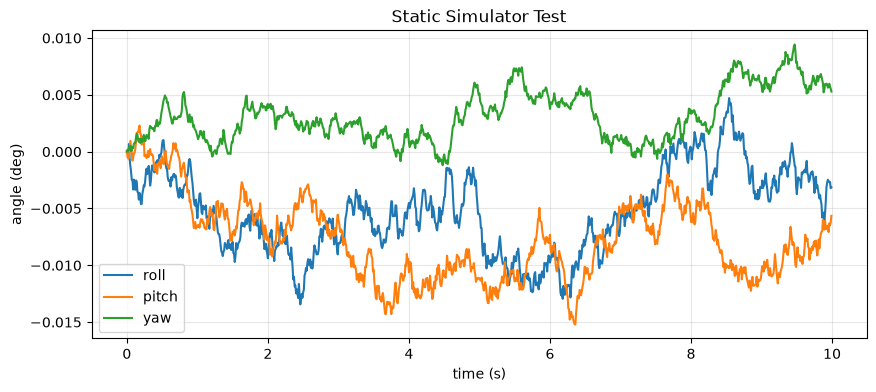

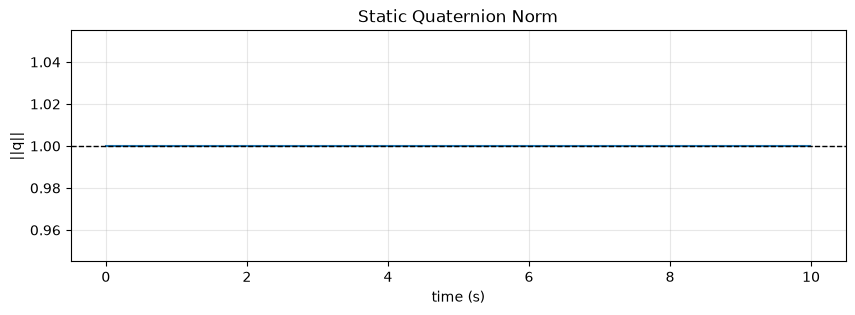

final q:  [ 9.99999997e-01 -2.73771469e-05 -4.92608100e-05  4.61304555e-05]
final euler deg:  [[-7.28641111e-05  1.09930770e-04  3.37014597e-05]
 [ 8.10156291e-05 -4.82585657e-04 -1.43642751e-05]
 [-2.50798190e-04 -6.05271399e-04  2.21212382e-04]
 ...
 [-2.66967221e-03 -6.31402807e-03  5.98028020e-03]
 [-2.66435160e-03 -6.49232417e-03  5.74241623e-03]
 [-3.20909512e-03 -6.24767857e-03  5.54744302e-03]]
max abs roll/pitch deg:  [0.01344172 0.01520914]
yaw start/end deg:  3.370145974956702e-05 0.005286315369668922
max quaternion norm error:  2.220446049250313e-16


In [349]:
filt, quats, eulers, norms = run_filter_imu(
    gyro,
    accel,
    dt, 
)

eulers_deg = plot_euler(
    t,
    eulers,
    "Static Simulator Test"
)
plot_quat (t, norms, "Static Quaternion Norm")
print ('final q: ', quats[-1])
print ('final euler deg: ', eulers_deg[:-1])
print ('max abs roll/pitch deg: ', np.max (np.abs (eulers_deg[:, :2]), axis = 0))
print ('yaw start/end deg: ', eulers_deg[0, 2], eulers_deg[-1, 2])
print ('max quaternion norm error: ', np.max (np.abs (norms - 1.0)))

In [350]:
assert np.max (np.abs (norms - 1.0)) < 1e-6 #quat norm should remain 1
assert np.max (np.abs (eulers_deg[:, 0])) < 5.0 #roll should stay near zero
assert np.max (np.abs (eulers_deg[:, 1])) < 5.0 #pitch should stay near 0

# Constant Yaw-rate test

In [351]:
#Generate orientation
duration = 5.0
n = int (duration * sample_rate_hz)
G = 9.81

t = np.arange (n) * dt
freq = 0.5
omega = 2.0 * np.pi * freq
true_roll = 0.00025 * np.sin(omega * t)
true_pitch = 0.00015 * np.sin(omega * t)
true_yaw = 0.00020 * np.sin(omega * t)

true_roll_rate = 0.00025 * omega * np.cos (omega * t)
true_pitch_rate = 0.00015 * omega * np.cos (omega * t)
true_yaw_rate = 0.00020 * omega * np.cos (omega * t)

true_gyro = np.column_stack ([
    true_roll_rate,
    true_pitch_rate,
    true_yaw_rate,
])

In [352]:
true_accel = np.zeros ((n, 3))
for i in range (n): 
    roll = true_roll[i]
    pitch = true_pitch[i]
    true_accel[i, 0] = -G * np.sin (pitch)
    true_accel[i, 1] = G * np.sin(roll) * np.cos(pitch)
    true_accel[i, 2] = G * np.cos (roll) * np.cos(pitch)

t, gyro_meas, accel_meas = sim.simulate(
    true_gyro, true_accel, duration
)

gyro_yaw = np.zeros (n)
gyro_pitch = np.zeros (n)
gyro_roll = np.zeros (n)

gyro_yaw[1: ] = np.cumsum (true_gyro[:-1, 2]) * dt
gyro_pitch[1: ] = np.cumsum (true_gyro[:-1, 1]) * dt
gyro_roll[1: ] = np.cumsum (true_gyro[:-1, 0]) * dt

noisy_gyro_yaw = np.zeros(n)
noisy_gyro_pitch = np.zeros(n)
noisy_gyro_roll = np.zeros(n)

noisy_gyro_yaw[1:] = np.cumsum(gyro_meas[:-1, 2]) * dt
noisy_gyro_pitch[1:] = np.cumsum(gyro_meas[:-1, 1]) * dt
noisy_gyro_roll[1:] = np.cumsum(gyro_meas[:-1, 0]) * dt

raw_accel_roll = np.arctan2 (
    accel_meas[:, 1],
    accel_meas[:, 2],
)

raw_accel_pitch = np.arctan2 (
    -accel_meas[:, 0],
    np.sqrt (
        accel_meas[:, 1] ** 2
        + 
        accel_meas[:, 2] ** 2
    )
)

filt, quats, eulers, norms = run_filter_imu(
    gyro_meas,
    accel_meas,
    dt,
    zeta = 5e-5,
)

madgwick_roll, madgwick_pitch, madgwick_yaw = eulers[:, 0], eulers[:, 1], eulers[:, 2]

# Roll Estimation

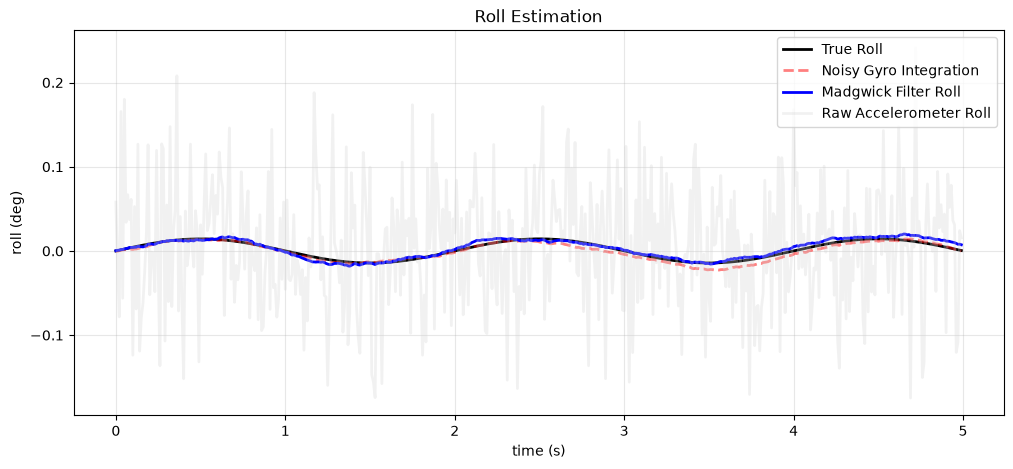

In [353]:
plt.figure(figsize=(12, 5))
plt.plot (t, np.rad2deg(true_roll), "k", linewidth = 2, label = 'True Roll')
plt.plot (t, np.rad2deg(noisy_gyro_roll), 'r--', linewidth = 2, alpha = 0.5, label = "Noisy Gyro Integration")
plt.plot (t, np.rad2deg(madgwick_roll), 'b', linewidth = 2, label = 'Madgwick Filter Roll')
plt.plot (t, np.rad2deg(raw_accel_roll), "lightgray", linewidth = 2, alpha = 0.3, label = 'Raw Accelerometer Roll')
plt.xlabel('time (s)')
plt.ylabel ('roll (deg)')
plt.title ('Roll Estimation')
plt.grid (alpha = 0.3)
plt.legend()
plt.show()


# Pitch Estimation

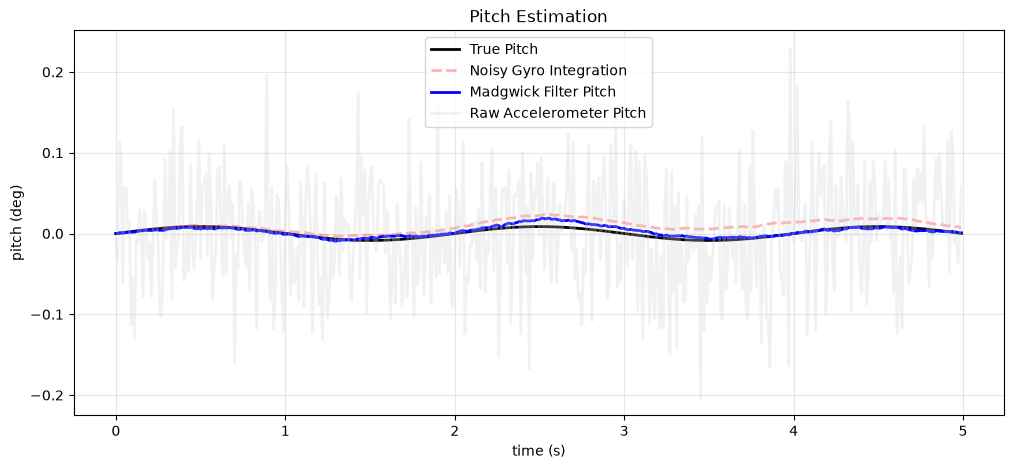

In [354]:
plt.figure(figsize=(12, 5))
plt.plot (t, np.rad2deg(true_pitch), "k", linewidth = 2, label = 'True Pitch')
plt.plot (t, np.rad2deg(noisy_gyro_pitch), 'r--', linewidth = 2, alpha = 0.3, label = "Noisy Gyro Integration")
plt.plot (t, np.rad2deg(madgwick_pitch), 'b', linewidth = 2, label = 'Madgwick Filter Pitch')
plt.plot (t, np.rad2deg(raw_accel_pitch), "lightgray", linewidth = 2, alpha = 0.3, label = 'Raw Accelerometer Pitch')
plt.xlabel('time (s)')
plt.ylabel ('pitch (deg)')
plt.title ('Pitch Estimation')
plt.grid (alpha = 0.3)
plt.legend()
plt.show()

# Yaw Estimation

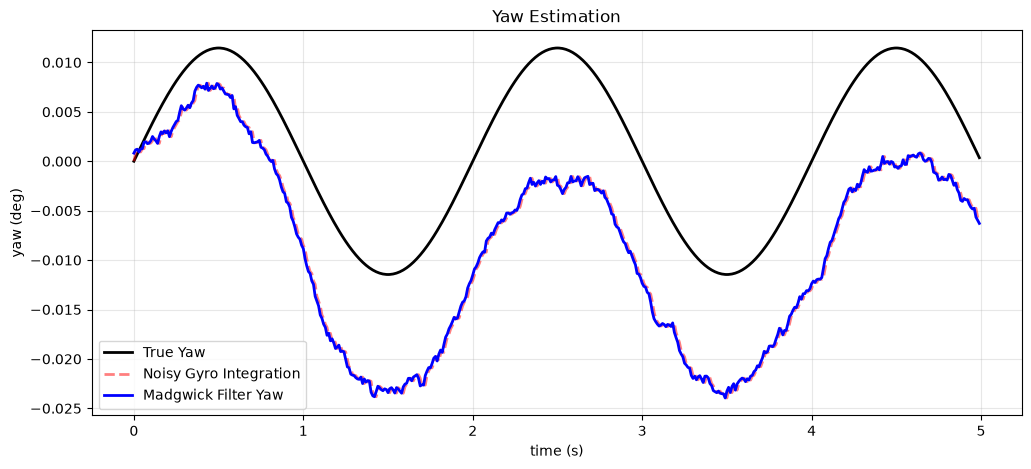

In [355]:
plt.figure(figsize=(12, 5))
plt.plot (t, np.rad2deg(true_yaw), "k", linewidth = 2, label = 'True Yaw')
plt.plot (t, np.rad2deg(noisy_gyro_yaw), 'r--', linewidth = 2, alpha = 0.5, label = "Noisy Gyro Integration")
plt.plot (t, np.rad2deg(madgwick_yaw), 'b', linewidth = 2, label = 'Madgwick Filter Yaw')
plt.xlabel('time (s)')
plt.ylabel ('yaw (deg)')
plt.title ('Yaw Estimation')
plt.grid (alpha = 0.3)
plt.legend()
plt.show()